Shape: (163830, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163830 entries, 0 to 163829
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   TimeStamp  163830 non-null  float64
 1   Ax         163830 non-null  float64
 2   Ay         163830 non-null  float64
 3   Az         163830 non-null  float64
 4   Gx         163830 non-null  float64
 5   Gy         163829 non-null  float64
 6   Gz         163829 non-null  float64
 7   Mx         163829 non-null  float64
 8   My         163829 non-null  float64
 9   Mz         163829 non-null  float64
 10  User       163829 non-null  float64
 11  Activity   163829 non-null  object 
dtypes: float64(11), object(1)
memory usage: 15.0+ MB
None
          TimeStamp             Ax             Ay             Az  \
count  1.638300e+05  163830.000000  163830.000000  163830.000000   
mean   1.554418e+12      -6.131191      -3.544512       1.662429   
std    4.604150e+08       5.1614

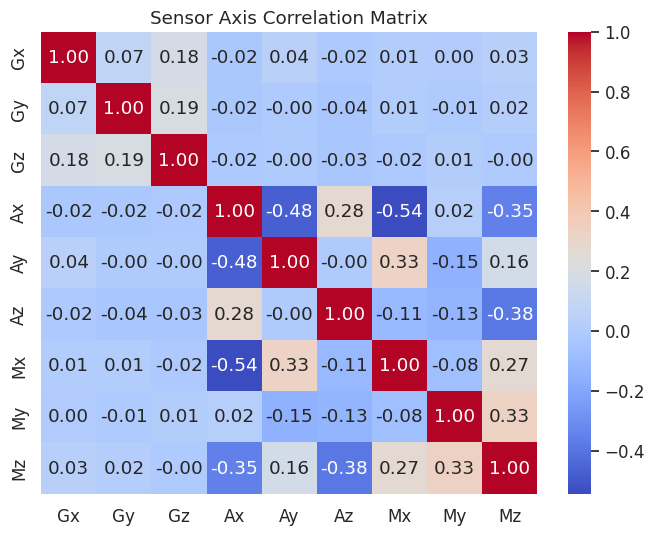

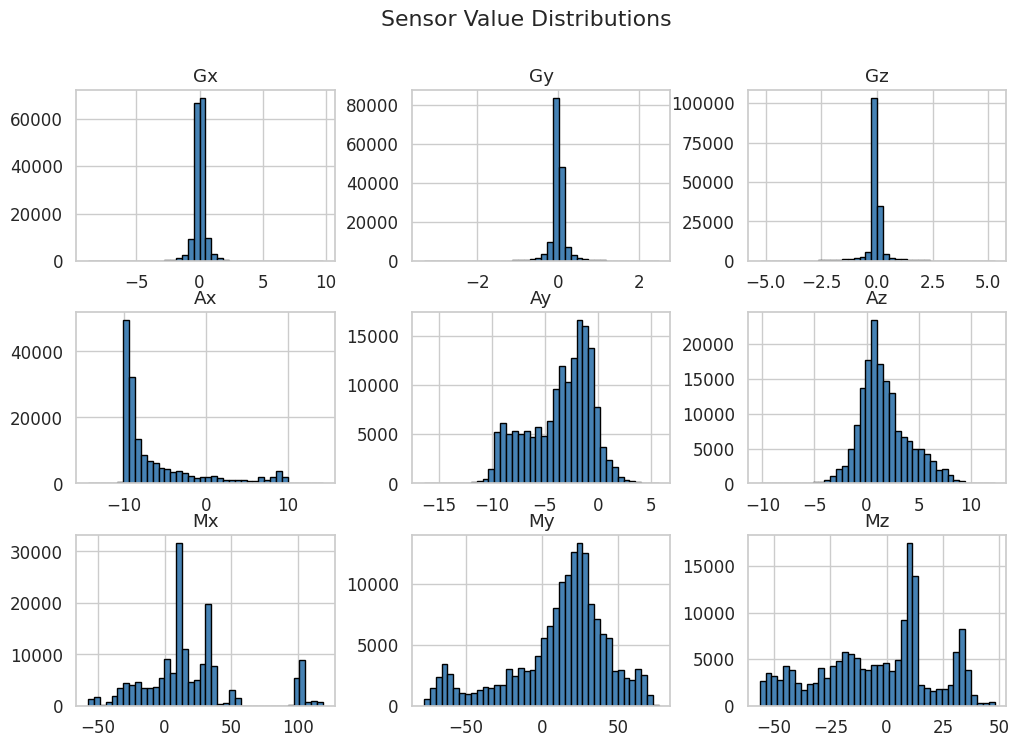

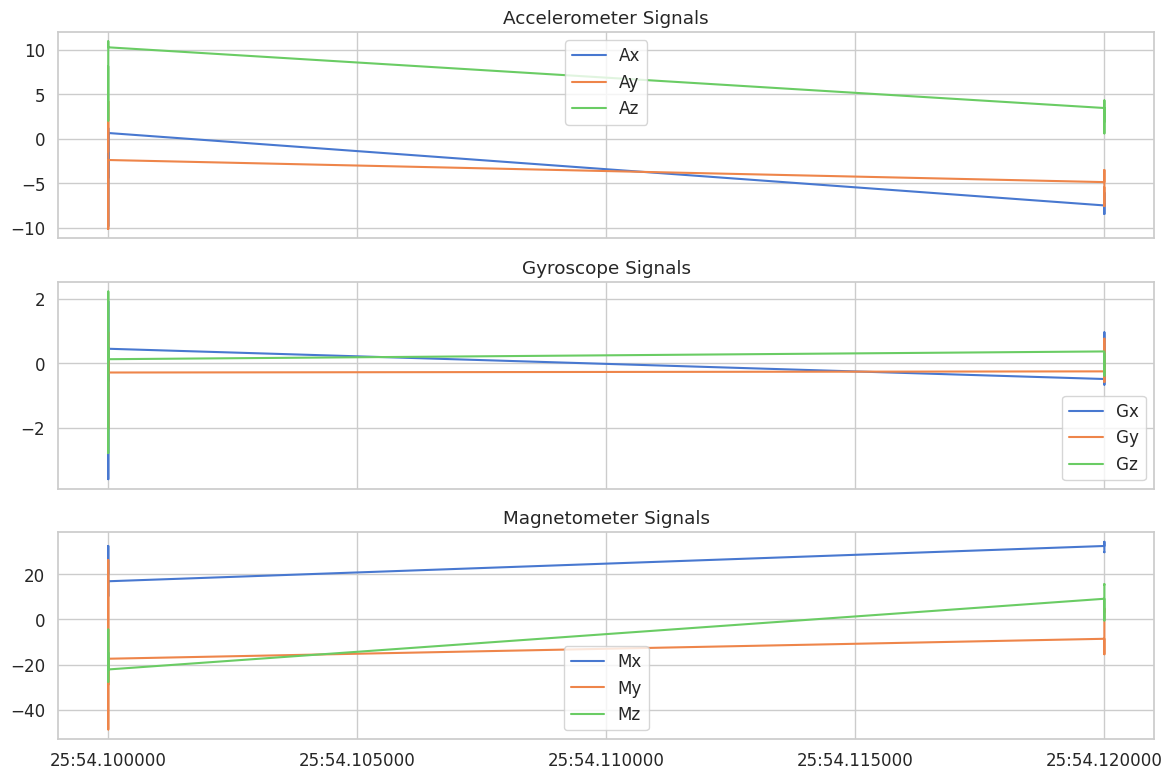

/tmp/ipython-input-2405203118.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Activity', order=df['Activity'].value_counts().index, palette='viridis')


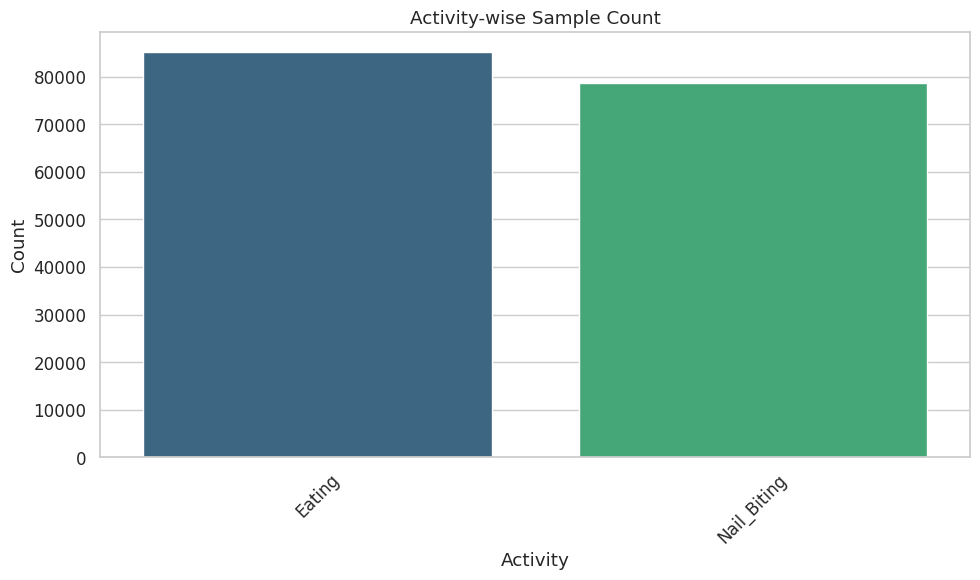

/tmp/ipython-input-2405203118.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='User', palette='coolwarm')


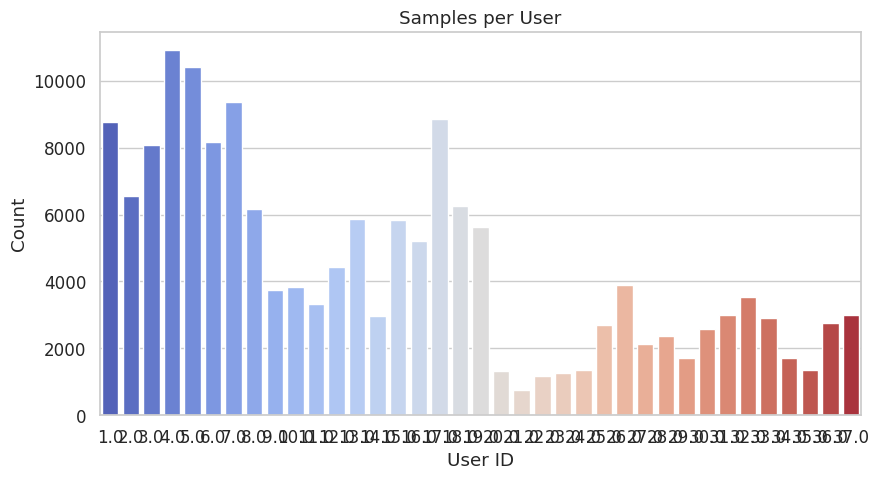

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

df = pd.read_csv("/content/stresSense.csv")

print("Shape:", df.shape)
print(df.info())
print(df.describe())
print("Null Values:\n", df.isnull().sum())


numeric_cols = ['Gx','Gy','Gz','Ax','Ay','Az','Mx','My','Mz']
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Sensor Axis Correlation Matrix")
plt.show()

df[numeric_cols].hist(figsize=(12, 8), bins=40, color='steelblue', edgecolor='black')
plt.suptitle("Sensor Value Distributions")
plt.show()

df['TimeStamp'] = pd.to_datetime(df['TimeStamp'], errors='coerce')

fig, ax = plt.subplots(3,1,figsize=(12,8), sharex=True)
ax[0].plot(df['TimeStamp'][:2000], df['Ax'][:2000], label='Ax')
ax[0].plot(df['TimeStamp'][:2000], df['Ay'][:2000], label='Ay')
ax[0].plot(df['TimeStamp'][:2000], df['Az'][:2000], label='Az')
ax[0].legend()
ax[0].set_title("Accelerometer Signals")

ax[1].plot(df['TimeStamp'][:2000], df['Gx'][:2000], label='Gx')
ax[1].plot(df['TimeStamp'][:2000], df['Gy'][:2000], label='Gy')
ax[1].plot(df['TimeStamp'][:2000], df['Gz'][:2000], label='Gz')
ax[1].legend()
ax[1].set_title("Gyroscope Signals")

ax[2].plot(df['TimeStamp'][:2000], df['Mx'][:2000], label='Mx')
ax[2].plot(df['TimeStamp'][:2000], df['My'][:2000], label='My')
ax[2].plot(df['TimeStamp'][:2000], df['Mz'][:2000], label='Mz')
ax[2].legend()
ax[2].set_title("Magnetometer Signals")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Activity', order=df['Activity'].value_counts().index, palette='viridis')
plt.xticks(rotation=45)
plt.xlabel("Activity")
plt.ylabel("Count")
plt.title("Activity-wise Sample Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sns.countplot(data=df, x='User', palette='coolwarm')
plt.xlabel("User ID")
plt.ylabel("Count")
plt.title("Samples per User")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score





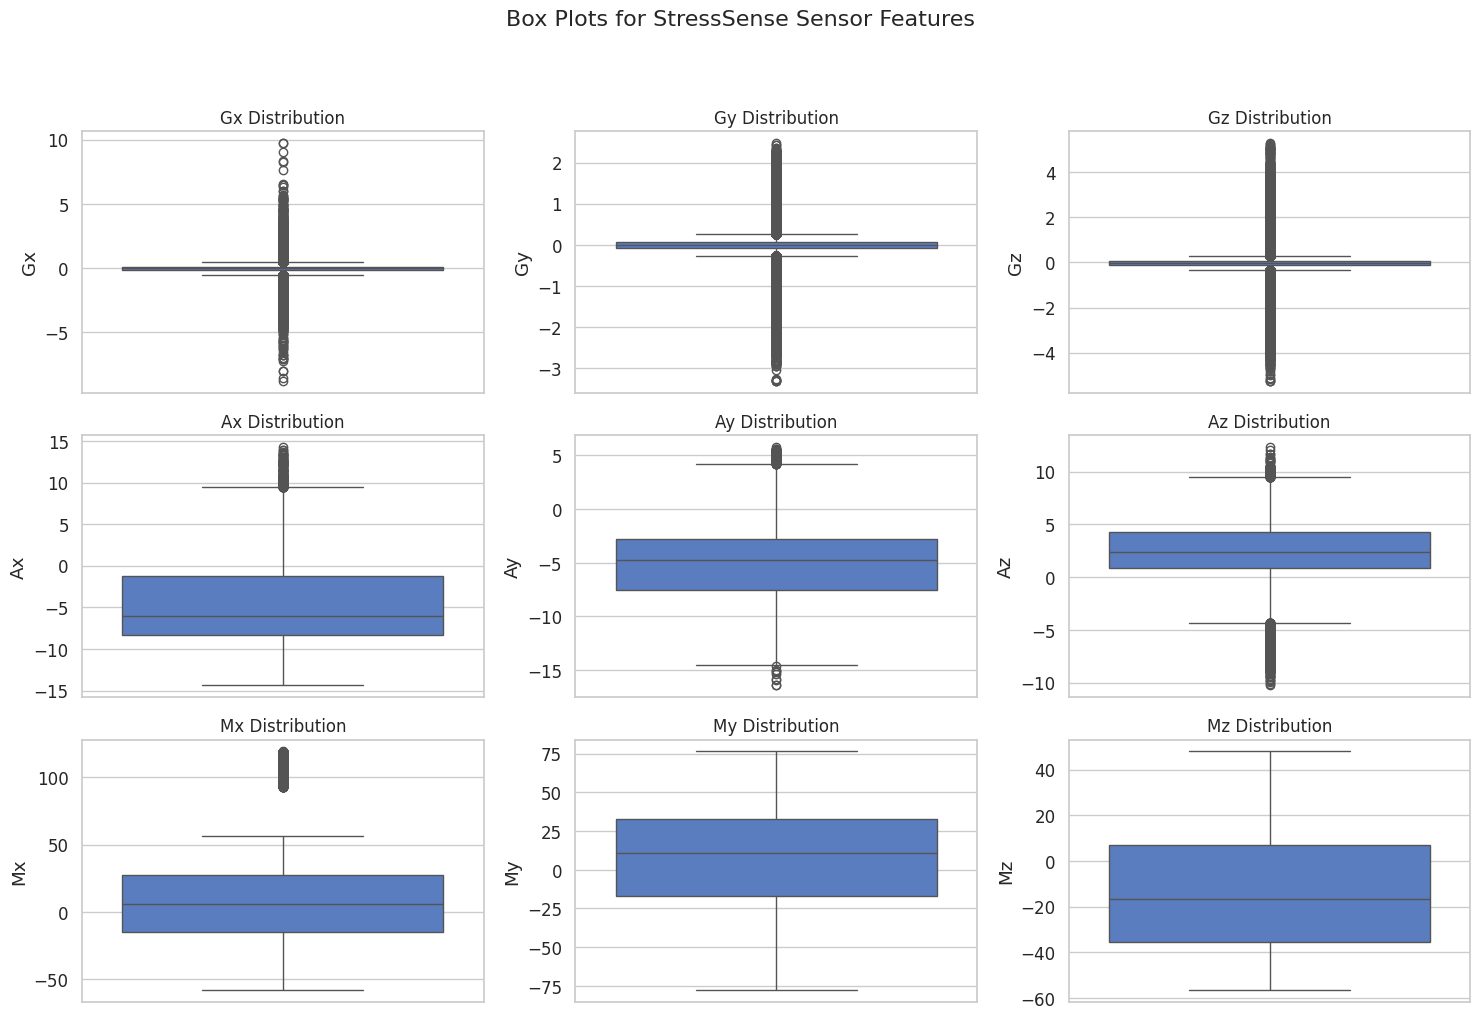

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']

plt.figure(figsize=(15, 10))
plt.suptitle('Box Plots for StressSense Sensor Features', fontsize=16, y=1.02)

for i, feature in enumerate(core_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[feature])
    plt.title(f'{feature} Distribution', fontsize=12)
    plt.ylabel(feature)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix


core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']
df_data = df[core_features].copy()

scaler_z = StandardScaler()
Z_scores = scaler_z.fit_transform(df_data[core_features])

max_abs_Z = np.max(np.abs(Z_scores), axis=1)

Z_THRESHOLD = 3.0
df_data['TimeStamp'] = pd.to_datetime(df['TimeStamp'])

df_data['Z_Anomaly_Label'] = (max_abs_Z > Z_THRESHOLD).astype(int)


df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)

IF_features = core_features + ['A_mag', 'G_mag', 'M_mag']

scaler_if = StandardScaler()
X_scaled = scaler_if.fit_transform(df_data[IF_features])

if_model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

if_model.fit(X_scaled)
if_predictions = if_model.predict(X_scaled)

df_data['IF_Prediction'] = np.where(if_predictions == -1, 1, 0)


Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['IF_Prediction']

z_anomaly_count = df_data['Z_Anomaly_Label'].sum()
if_anomaly_count = df_data['IF_Prediction'].sum()
total_records = len(df_data)

print(f"2. Isolation Forest Predicted Anomalies (Contam 0.01): {if_anomaly_count}")

print("\n----------------- Confusion Matrix -----------------")
print(confusion_matrix(Y_true, Y_pred))

print("\n--------------- Classification Report ----------------")
report = classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)'], output_dict=True)

# Print individual metrics clearly
print(f"Overall Accuracy: {report['accuracy']:.4f}")
print("\n--- Metrics for Anomaly Class (1) ---")
print(f"Precision: {report['Anomaly (1)']['precision']:.4f}")
print(f"Recall: {report['Anomaly (1)']['recall']:.4f}")
print(f"F1-Score: {report['Anomaly (1)']['f1-score']:.4f}")
print("--------------------------------------------------\n")

2. Isolation Forest Predicted Anomalies (Contam 0.01): 497

----------------- Confusion Matrix -----------------
[[46078     3]
 [ 3120   494]]

--------------- Classification Report ----------------
Overall Accuracy: 0.9372

--- Metrics for Anomaly Class (1) ---
Precision: 0.9940
Recall: 0.1367
F1-Score: 0.2403
--------------------------------------------------



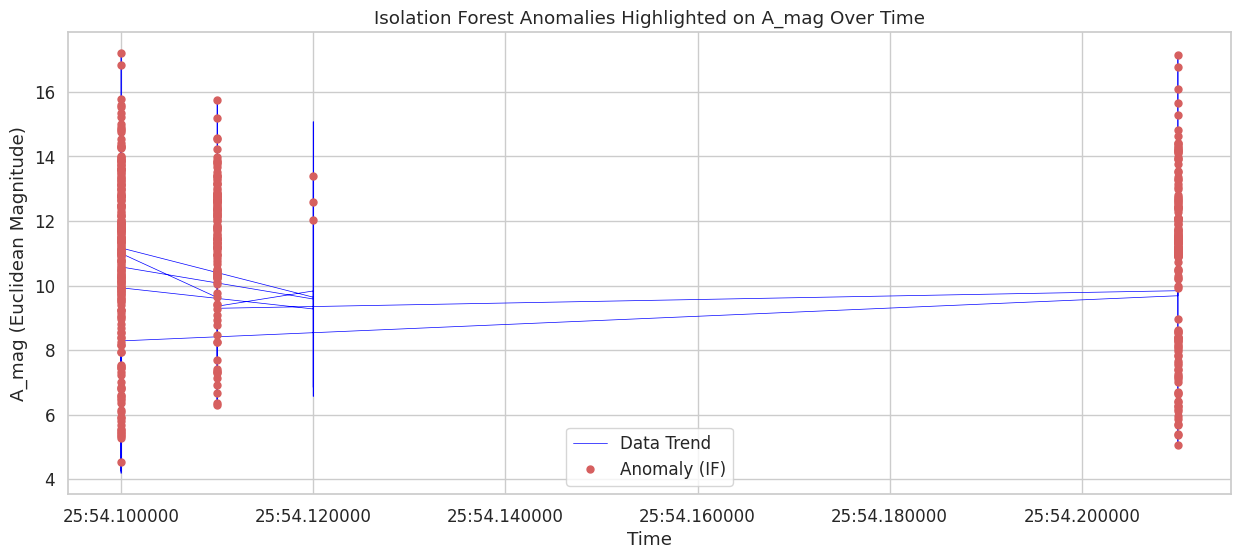

In [ ]:
feature_to_plot = 'A_mag'
df_anomalies = df_data[df_data['IF_Prediction'] == 1]


plt.figure(figsize=(15, 6))

plt.plot(
    df_data['TimeStamp'],
    df_data[feature_to_plot],
    color='blue',
    linewidth=0.5,
    label='Data Trend'
)

plt.plot(
    df_anomalies['TimeStamp'],
    df_anomalies[feature_to_plot],
    'ro',
    markersize=5,
    label='Anomaly (IF)'
)

plt.title(f'Isolation Forest Anomalies Highlighted on {feature_to_plot} Over Time')
plt.xlabel('Time')
plt.ylabel(f'{feature_to_plot} (Euclidean Magnitude)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = df.dropna()
print(df.isnull().sum())

TimeStamp    0
Ax           0
Ay           0
Az           0
Gx           0
Gy           0
Gz           0
Mx           0
My           0
Mz           0
User         0
Activity     0
dtype: int64


In [ ]:
#one class svm

2. One-Class SVM Predicted Anomalies (nu 0.01): 517

----------------- Confusion Matrix -----------------
[[46007    73]
 [ 3170   444]]

--------------- Classification Report ----------------
Overall Accuracy: 0.9347

--- Metrics for Anomaly Class (1) ---
Precision: 0.8588
Recall: 0.1229
F1-Score: 0.2150
--------------------------------------------------



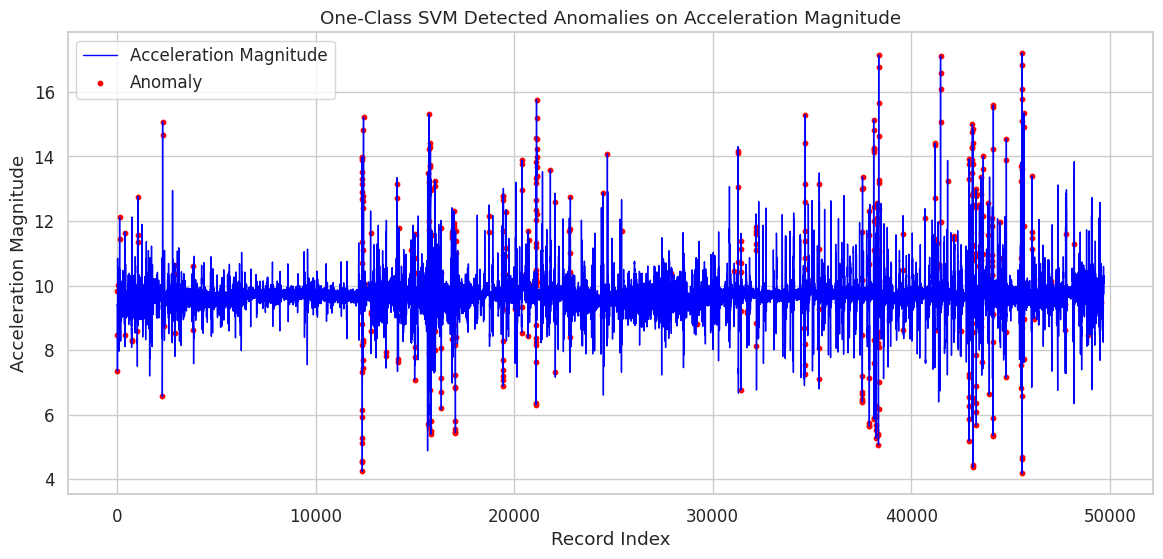

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import classification_report, confusion_matrix

core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']
df_data = df[core_features].copy()

scaler_z = StandardScaler()
Z_scores = scaler_z.fit_transform(df_data[core_features])
max_abs_Z = np.max(np.abs(Z_scores), axis=1)
Z_THRESHOLD = 3.0
df_data['Z_Anomaly_Label'] = (max_abs_Z > Z_THRESHOLD).astype(int)

df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)

OCSVM_features = core_features + ['A_mag', 'G_mag', 'M_mag']
scaler_ocsvm = StandardScaler()
X_scaled = scaler_ocsvm.fit_transform(df_data[OCSVM_features])

ocsvm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.01)
ocsvm_model.fit(X_scaled)
ocsvm_predictions = ocsvm_model.predict(X_scaled)
df_data['OCSVM_Prediction'] = np.where(ocsvm_predictions == -1, 1, 0)

Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['OCSVM_Prediction']

z_anomaly_count = df_data['Z_Anomaly_Label'].sum()
ocsvm_anomaly_count = df_data['OCSVM_Prediction'].sum()
total_records = len(df_data)

print(f"2. One-Class SVM Predicted Anomalies (nu 0.01): {ocsvm_anomaly_count}")
print("\n----------------- Confusion Matrix -----------------")
print(confusion_matrix(Y_true, Y_pred))

print("\n--------------- Classification Report ----------------")
report = classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)'], output_dict=True)
print(f"Overall Accuracy: {report['accuracy']:.4f}")
print("\n--- Metrics for Anomaly Class (1) ---")
print(f"Precision: {report['Anomaly (1)']['precision']:.4f}")
print(f"Recall: {report['Anomaly (1)']['recall']:.4f}")
print(f"F1-Score: {report['Anomaly (1)']['f1-score']:.4f}")
print("--------------------------------------------------\n")

plt.figure(figsize=(14,6))
plt.plot(df.index, df_data['A_mag'], label='Acceleration Magnitude', color='blue', linewidth=1)
plt.scatter(df.index[df_data['OCSVM_Prediction']==1], df_data['A_mag'][df_data['OCSVM_Prediction']==1],
            color='red', s=10, label='Anomaly')
plt.title("One-Class SVM Detected Anomalies on Acceleration Magnitude")
plt.xlabel("Record Index")
plt.ylabel("Acceleration Magnitude")
plt.legend()
plt.show()


2. Local Outlier Factor Predicted Anomalies (Contam 0.01): 497

----------------- Confusion Matrix -----------------
[[45605   475]
 [ 3592    22]]

--------------- Classification Report ----------------
Overall Accuracy: 0.9182

--- Metrics for Anomaly Class (1) ---
Precision: 0.0443
Recall: 0.0061
F1-Score: 0.0107
--------------------------------------------------



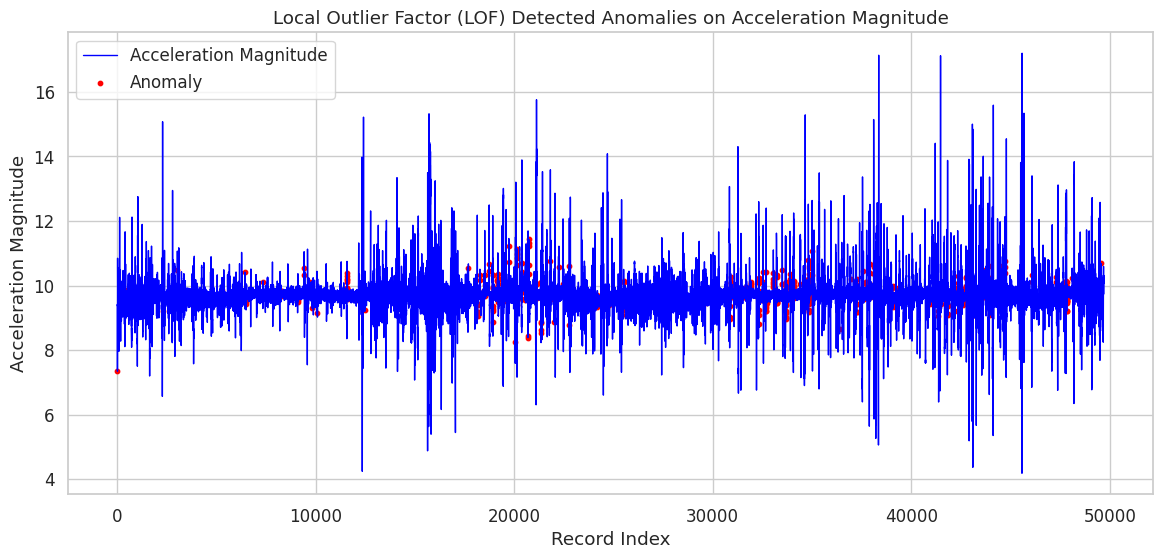

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix

core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']
df_data = df[core_features].copy()

scaler_z = StandardScaler()
Z_scores = scaler_z.fit_transform(df_data[core_features])
max_abs_Z = np.max(np.abs(Z_scores), axis=1)
Z_THRESHOLD = 3.0
df_data['Z_Anomaly_Label'] = (max_abs_Z > Z_THRESHOLD).astype(int)

df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)

LOF_features = core_features + ['A_mag', 'G_mag', 'M_mag']
scaler_lof = StandardScaler()
X_scaled = scaler_lof.fit_transform(df_data[LOF_features])

lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.01, novelty=False)
lof_predictions = lof_model.fit_predict(X_scaled)
df_data['LOF_Prediction'] = np.where(lof_predictions == -1, 1, 0)

Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['LOF_Prediction']

z_anomaly_count = df_data['Z_Anomaly_Label'].sum()
lof_anomaly_count = df_data['LOF_Prediction'].sum()
total_records = len(df_data)

print(f"2. Local Outlier Factor Predicted Anomalies (Contam 0.01): {lof_anomaly_count}")
print("\n----------------- Confusion Matrix -----------------")
print(confusion_matrix(Y_true, Y_pred))

print("\n--------------- Classification Report ----------------")
report = classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)'], output_dict=True)
print(f"Overall Accuracy: {report['accuracy']:.4f}")
print("\n--- Metrics for Anomaly Class (1) ---")
print(f"Precision: {report['Anomaly (1)']['precision']:.4f}")
print(f"Recall: {report['Anomaly (1)']['recall']:.4f}")
print(f"F1-Score: {report['Anomaly (1)']['f1-score']:.4f}")
print("--------------------------------------------------\n")

plt.figure(figsize=(14,6))
plt.plot(df.index, df_data['A_mag'], label='Acceleration Magnitude', color='blue', linewidth=1)
plt.scatter(df.index[df_data['LOF_Prediction']==1], df_data['A_mag'][df_data['LOF_Prediction']==1],
            color='red', s=10, label='Anomaly')
plt.title("Local Outlier Factor (LOF) Detected Anomalies on Acceleration Magnitude")
plt.xlabel("Record Index")
plt.ylabel("Acceleration Magnitude")
plt.legend()
plt.show()


In [ ]:
pip install -U stumpy


[[30705   102]
 [18766   121]]
              precision    recall  f1-score   support

  Normal (0)       0.62      1.00      0.76     30807
 Anomaly (1)       0.54      0.01      0.01     18887

    accuracy                           0.62     49694
   macro avg       0.58      0.50      0.39     49694
weighted avg       0.59      0.62      0.48     49694

Detected anomalies: 223


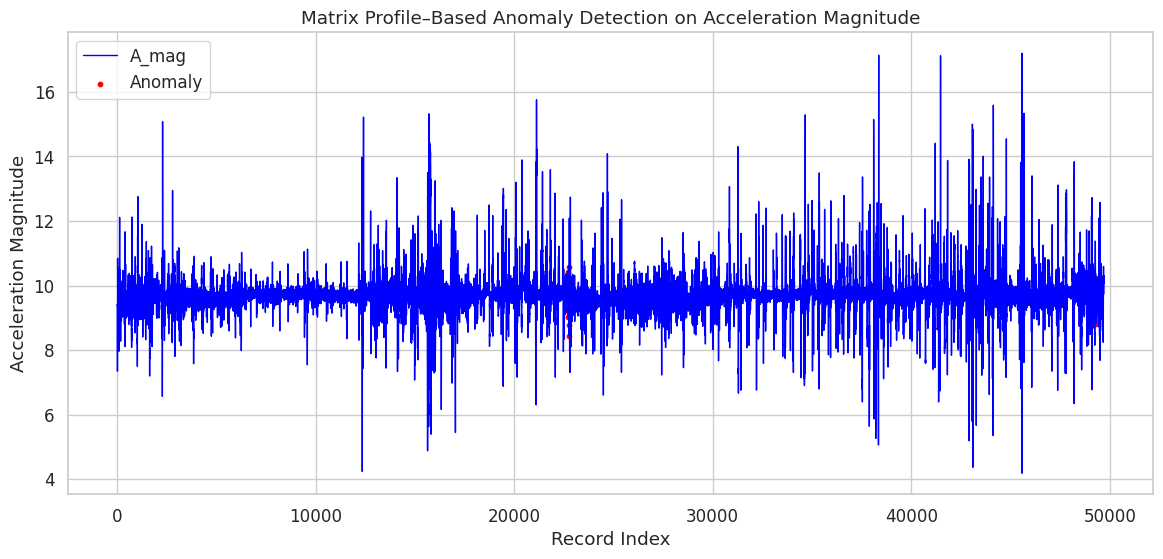

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import classification_report, confusion_matrix

df_data = df.copy()
df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)

combined_signal = (df_data['A_mag'] + df_data['G_mag'] + df_data['M_mag']).values
window_size = 100
matrix_profile = stumpy.stump(combined_signal, m=window_size)
mp_values = matrix_profile[:, 0]
top_k = 10
# Use stumpy.stump to find discords for a single time series
mp = stumpy.stump(combined_signal, m=window_size)
discord_idx = np.argsort(mp[:,0])[-top_k:]
discords = [(i, i + window_size) for i in discord_idx]

anomaly_indices = np.zeros(len(combined_signal))
for start_idx, end_idx in discords:
    anomaly_indices[start_idx:end_idx] = 1

df_data['MatrixProfile_Pred'] = anomaly_indices
Z_scores = (combined_signal - np.mean(combined_signal)) / np.std(combined_signal)
df_data['Z_Anomaly_Label'] = (np.abs(Z_scores) > 3).astype(int)

Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['MatrixProfile_Pred']
print(confusion_matrix(Y_true, Y_pred))
print(classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)']))
print("Detected anomalies:", int(df_data['MatrixProfile_Pred'].sum()))

plt.figure(figsize=(14,6))
plt.plot(df_data.index, df_data['A_mag'], label='A_mag', color='blue', linewidth=1)
plt.plot(df_data.index, df_data['G_mag'], label='G_mag', color='green', linewidth=1)
plt.plot(df_data.index, df_data['M_mag'], label='M_mag', color='orange', linewidth=1)
plt.scatter(df_data.index[df_data['MatrixProfile_Pred']==1],
            df_data['A_mag'][df_data['MatrixProfile_Pred']==1],
            color='red', s=10, label='Anomaly')
plt.title("Matrix Profile–Based Anomaly Detection using Combined Magnitudes")
plt.xlabel("Record Index")
plt.ylabel("Magnitude")
plt.legend()
plt.show()

In [ ]:
#deep learning models

Epoch 1/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9099
Epoch 2/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6219
Epoch 3/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4513
Epoch 4/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3662
Epoch 5/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3194
Epoch 6/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2801
Epoch 7/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2514
Epoch 8/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2269
Epoch 9/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2095
Epoch 10/10
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1956
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Confusion Matrix:
[[46080     0]
 [ 3117   497]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.94      1.00      0.97     46080
 Anomaly (1)       1.00      0.14      0.24      3614

    accuracy                           0.94     

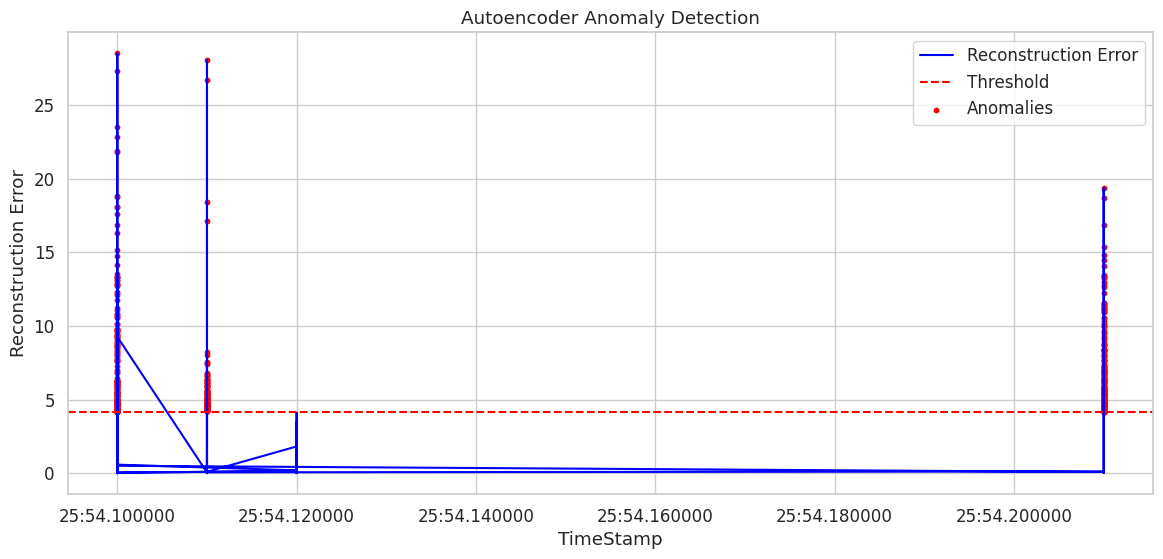

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']
df_data = df[['TimeStamp'] + core_features].copy()

df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)

Z_scaler = StandardScaler()
Z_scores = Z_scaler.fit_transform(df_data[core_features])
max_abs_Z = np.max(np.abs(Z_scores), axis=1)
df_data['Z_Anomaly_Label'] = (max_abs_Z > 3).astype(int)

AE_features = core_features + ['A_mag', 'G_mag', 'M_mag']
scaler_ae = StandardScaler()
X_scaled = scaler_ae.fit_transform(df_data[AE_features])

normal_data = X_scaled[df_data['Z_Anomaly_Label'] == 0]

input_dim = X_scaled.shape[1]
encoding_dim = 6

input_layer = tf.keras.layers.Input(shape=(input_dim,))
encoded = tf.keras.layers.Dense(encoding_dim, activation='relu')(input_layer)
decoded = tf.keras.layers.Dense(input_dim, activation='linear')(encoded)
autoencoder = tf.keras.models.Model(inputs=input_layer, outputs=decoded)

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(normal_data, normal_data, epochs=10, batch_size=256, shuffle=True, verbose=1)

reconstructions = autoencoder.predict(X_scaled)
mse = np.mean(np.square(X_scaled - reconstructions), axis=1)
threshold = np.percentile(mse, 99)
df_data['AE_Prediction'] = (mse > threshold).astype(int)

Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['AE_Prediction']

print("\nConfusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

plt.figure(figsize=(14,6))
plt.plot(df_data['TimeStamp'], mse, label='Reconstruction Error', color='blue')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.scatter(df_data['TimeStamp'][df_data['AE_Prediction']==1],
            mse[df_data['AE_Prediction']==1],
            color='red', s=10, label='Anomalies')
plt.xlabel("TimeStamp")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Anomaly Detection")
plt.legend()
plt.show()


Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - kl_loss: 0.3654 - loss: 10.0372 - recon_loss: 9.6718
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - kl_loss: 0.4300 - loss: 8.9923 - recon_loss: 8.5623
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 0.5726 - loss: 8.7978 - recon_loss: 8.2253
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 0.7670 - loss: 8.6654 - recon_loss: 7.8984
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - kl_loss: 0.8747 - loss: 8.5987 - recon_loss: 7.7240
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - kl_loss: 0.9275 - loss: 8.5871 - recon_loss: 7.6596
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 0.9426 - loss: 8.5537 - recon_loss: 7.6111
Epoch 8/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - kl_loss: 0.9532 - loss: 8.5530 - recon_loss: 7.5997
Epoch 9/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - kl_loss: 0.9663 - loss: 8.5500 - recon_loss: 7.5837
Epoch 10/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 2

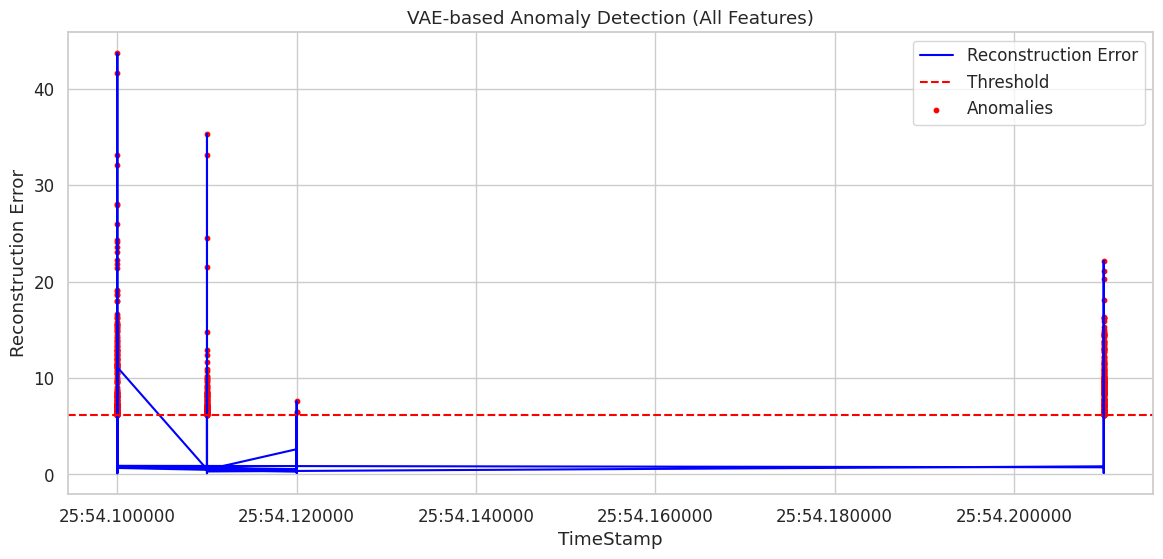

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=-1))
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=-1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": reconstruction_loss, "kl_loss": kl_loss}

core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']
df_data = df[['TimeStamp'] + core_features].copy()
df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)
scaler_z = StandardScaler()
Z_scores = scaler_z.fit_transform(df_data[core_features])
max_abs_Z = np.max(np.abs(Z_scores), axis=1)
df_data['Z_Anomaly_Label'] = (max_abs_Z > 3).astype(int)
VAE_features = core_features + ['A_mag', 'G_mag', 'M_mag']
scaler_vae = StandardScaler()
X_scaled = scaler_vae.fit_transform(df_data[VAE_features])
input_dim = X_scaled.shape[1]
latent_dim = 4
inputs = keras.Input(shape=(input_dim,))
h = layers.Dense(32, activation='relu')(inputs)
z_mean = layers.Dense(latent_dim)(h)
z_log_var = layers.Dense(latent_dim)(h)
def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon
z = layers.Lambda(sampling)([z_mean, z_log_var])
encoder = keras.Model(inputs, [z_mean, z_log_var, z])
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(32, activation='relu')(latent_inputs)
outputs = layers.Dense(input_dim, activation='sigmoid')(x)
decoder = keras.Model(latent_inputs, outputs)
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
normal_data = X_scaled[df_data['Z_Anomaly_Label'] == 0]
vae.fit(normal_data, epochs=20, batch_size=128, verbose=1)
z_mean, z_log_var, z = encoder.predict(X_scaled)
recon = decoder.predict(z)
mse = np.mean(np.square(X_scaled - recon), axis=1)
threshold = np.percentile(mse, 99)
df_data['VAE_Prediction'] = (mse > threshold).astype(int)
Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['VAE_Prediction']
print(confusion_matrix(Y_true, Y_pred))
print(classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)']))
plt.figure(figsize=(14,6))
plt.plot(df_data['TimeStamp'], mse, label='Reconstruction Error', color='blue')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.scatter(df_data['TimeStamp'][df_data['VAE_Prediction']==1], mse[df_data['VAE_Prediction']==1], color='red', s=10, label='Anomalies')
plt.xlabel("TimeStamp")
plt.ylabel("Reconstruction Error")
plt.title("VAE-based Anomaly Detection (All Features)")
plt.legend()
plt.show()


Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - loss: 0.5048
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - loss: 0.2415
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - loss: 0.1948
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 0.1769
Epoch 5/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - loss: 0.1680
Epoch 6/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - loss: 0.1568
Epoch 7/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - loss: 0.1504
Epoch 8/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 0.1438
Epoch 9/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - loss: 0.1378
Epoch 10/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - loss: 0.1326
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step

Confusion Matrix:
[[45712   324]
 [ 3435   173]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.93      0.99      0.96     46036
 Anomaly (1)       0.35      0.05      0.08      3608

    accuracy              

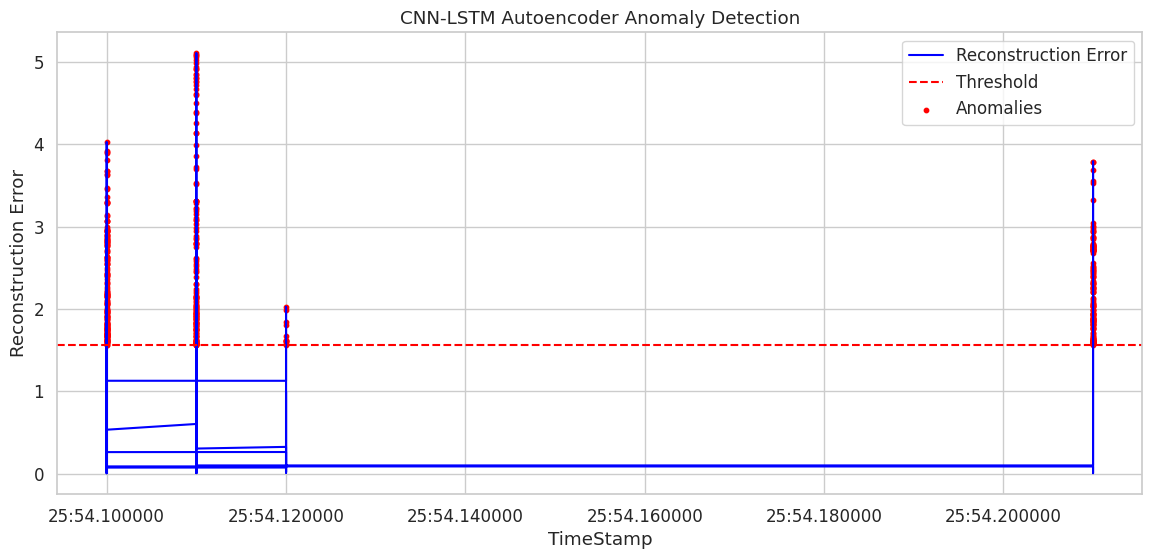

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']
df_data = df[['TimeStamp'] + core_features].copy()

df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)

scaler_z = StandardScaler()
Z_scores = scaler_z.fit_transform(df_data[core_features])
max_abs_Z = np.max(np.abs(Z_scores), axis=1)
df_data['Z_Anomaly_Label'] = (max_abs_Z > 3).astype(int)

features = core_features + ['A_mag', 'G_mag', 'M_mag']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_data[features])

window_size = 50
X_seq = []
for i in range(len(X_scaled) - window_size):
    X_seq.append(X_scaled[i:i+window_size])
X_seq = np.array(X_seq)

normal_seq = X_seq[df_data['Z_Anomaly_Label'][:-window_size] == 0]

input_shape = (window_size, X_seq.shape[2])

inputs = tf.keras.layers.Input(shape=input_shape)
x = tf.keras.layers.Conv1D(32, 3, padding='same', activation='relu')(inputs)
x = tf.keras.layers.MaxPooling1D(2)(x)
x = tf.keras.layers.LSTM(32, return_sequences=False)(x)
encoded = tf.keras.layers.Dense(16, activation='relu')(x)

x = tf.keras.layers.RepeatVector(window_size)(encoded)
x = tf.keras.layers.LSTM(32, return_sequences=True)(x)
x = tf.keras.layers.Conv1DTranspose(32, 3, padding='same', activation='relu')(x)
outputs = tf.keras.layers.Conv1D(X_seq.shape[2], 1, padding='same', activation='linear')(x)

cnn_lstm_autoencoder = tf.keras.models.Model(inputs, outputs)
cnn_lstm_autoencoder.compile(optimizer='adam', loss='mse')

cnn_lstm_autoencoder.fit(normal_seq, normal_seq, epochs=10, batch_size=128, verbose=1)

reconstructed = cnn_lstm_autoencoder.predict(X_seq)
mse = np.mean(np.square(X_seq - reconstructed), axis=(1,2))

threshold = np.percentile(mse, 99)
df_data = df_data.iloc[window_size:].copy()
df_data['CNNLSTM_Prediction'] = (mse > threshold).astype(int)

Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['CNNLSTM_Prediction']

print("\nConfusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

plt.figure(figsize=(14,6))
plt.plot(df_data['TimeStamp'], mse, label='Reconstruction Error', color='blue')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.scatter(df_data['TimeStamp'][df_data['CNNLSTM_Prediction']==1],
            mse[df_data['CNNLSTM_Prediction']==1],
            color='red', s=10, label='Anomalies')
plt.xlabel("TimeStamp")
plt.ylabel("Reconstruction Error")
plt.title("CNN-LSTM Autoencoder Anomaly Detection")
plt.legend()
plt.show()


Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 33s 63ms/step - loss: 0.4638
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - loss: 0.2485
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.2389
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - loss: 0.2294
Epoch 5/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - loss: 0.2335
Epoch 6/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - loss: 0.2315
Epoch 7/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - loss: 0.2281
Epoch 8/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - loss: 0.2303
Epoch 9/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - loss: 0.2286
Epoch 10/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - loss: 0.2280
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step

Confusion Matrix:
[[45700   336]
 [ 3447   161]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.93      0.99      0.96     46036
 Anomaly (1)       0.32      0.04      0.08      3608

    accuracy               

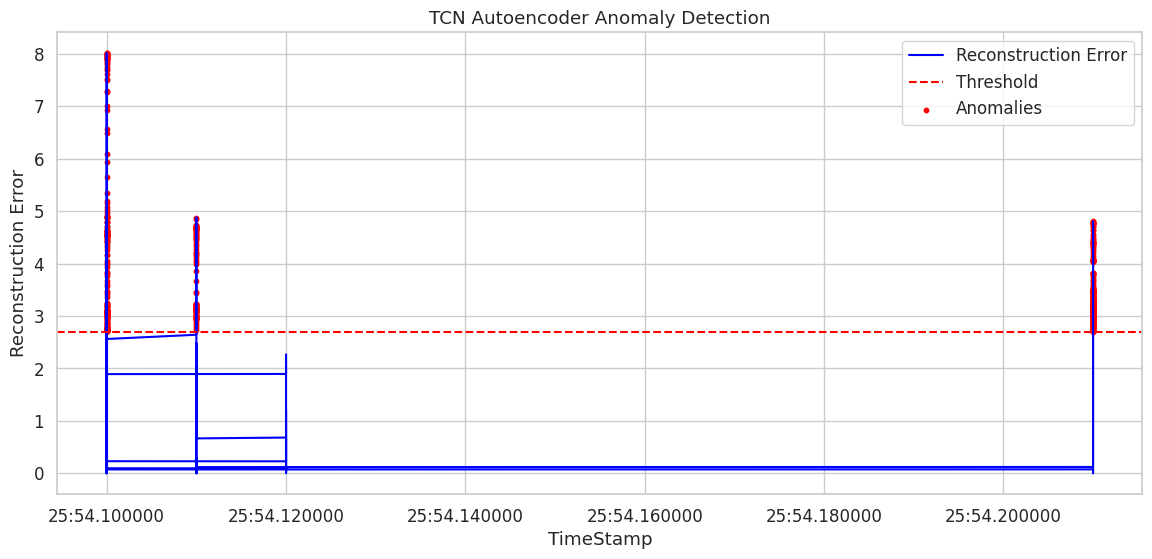

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

core_features = ['Gx', 'Gy', 'Gz', 'Ax', 'Ay', 'Az', 'Mx', 'My', 'Mz']
df_data = df[['TimeStamp'] + core_features].copy()

df_data['A_mag'] = np.sqrt(df_data['Ax']**2 + df_data['Ay']**2 + df_data['Az']**2)
df_data['G_mag'] = np.sqrt(df_data['Gx']**2 + df_data['Gy']**2 + df_data['Gz']**2)
df_data['M_mag'] = np.sqrt(df_data['Mx']**2 + df_data['My']**2 + df_data['Mz']**2)

scaler_z = StandardScaler()
Z_scores = scaler_z.fit_transform(df_data[core_features])
max_abs_Z = np.max(np.abs(Z_scores), axis=1)
df_data['Z_Anomaly_Label'] = (max_abs_Z > 3).astype(int)

features = core_features + ['A_mag', 'G_mag', 'M_mag']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_data[features])

window_size = 50
X_seq = []
for i in range(len(X_scaled) - window_size):
    X_seq.append(X_scaled[i:i+window_size])
X_seq = np.array(X_seq)

normal_seq = X_seq[df_data['Z_Anomaly_Label'][:-window_size] == 0]
input_shape = (window_size, X_seq.shape[2])

def TCN_block(x, filters, kernel_size, dilation_rate):
    conv1 = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate, activation='relu')(x)
    conv2 = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate, activation='relu')(conv1)
    shortcut = layers.Conv1D(filters, 1, padding='same')(x)
    return layers.Add()([conv2, shortcut])

inputs = layers.Input(shape=input_shape)
x = TCN_block(inputs, 32, 3, 1)
x = TCN_block(x, 32, 3, 2)
x = TCN_block(x, 32, 3, 4)
encoded = layers.GlobalAveragePooling1D()(x)
encoded = layers.Dense(16, activation='relu')(encoded)

x = layers.RepeatVector(window_size)(encoded)
x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
x = layers.Conv1D(32, 3, padding='same', activation='relu')(x)
outputs = layers.Conv1D(X_seq.shape[2], 1, activation='linear')(x)

tcn_autoencoder = models.Model(inputs, outputs)
tcn_autoencoder.compile(optimizer='adam', loss='mse')

tcn_autoencoder.fit(normal_seq, normal_seq, epochs=10, batch_size=128, verbose=1)

reconstructed = tcn_autoencoder.predict(X_seq)
mse = np.mean(np.square(X_seq - reconstructed), axis=(1,2))

threshold = np.percentile(mse, 99)
df_data = df_data.iloc[window_size:].copy()
df_data['TCN_Prediction'] = (mse > threshold).astype(int)

Y_true = df_data['Z_Anomaly_Label']
Y_pred = df_data['TCN_Prediction']

print("\nConfusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

plt.figure(figsize=(14,6))
plt.plot(df_data['TimeStamp'], mse, color='blue', label='Reconstruction Error')
plt.axhline(threshold, color='red', linestyle='--', label='Threshold')
plt.scatter(df_data['TimeStamp'][df_data['TCN_Prediction']==1],
            mse[df_data['TCN_Prediction']==1],
            color='red', s=10, label='Anomalies')
plt.xlabel("TimeStamp")
plt.ylabel("Reconstruction Error")
plt.title("TCN Autoencoder Anomaly Detection")
plt.legend()
plt.show()


Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 257s 666ms/step - loss: 0.3932
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 242s 672ms/step - loss: 0.2462
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 242s 674ms/step - loss: 0.2450
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 245s 680ms/step - loss: 0.2374
Epoch 5/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 238s 661ms/step - loss: 0.2386
Epoch 6/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 249s 693ms/step - loss: 0.2402
Epoch 7/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 238s 662ms/step - loss: 0.2363
Epoch 8/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 259s 654ms/step - loss: 0.2393
Epoch 9/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 236s 655ms/step - loss: 0.2377
Epoch 10/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 236s 655ms/step - loss: 0.2379
1552/1552 ━━━━━━━━━━━━━━━━━━━━ 101s 64ms/step

Confusion Matrix:
[[45704   332]
 [ 3443   165]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       0.93      0.99      0.96     46036
 Anomaly (1)       0.33      0.05      0.08      3608

    a

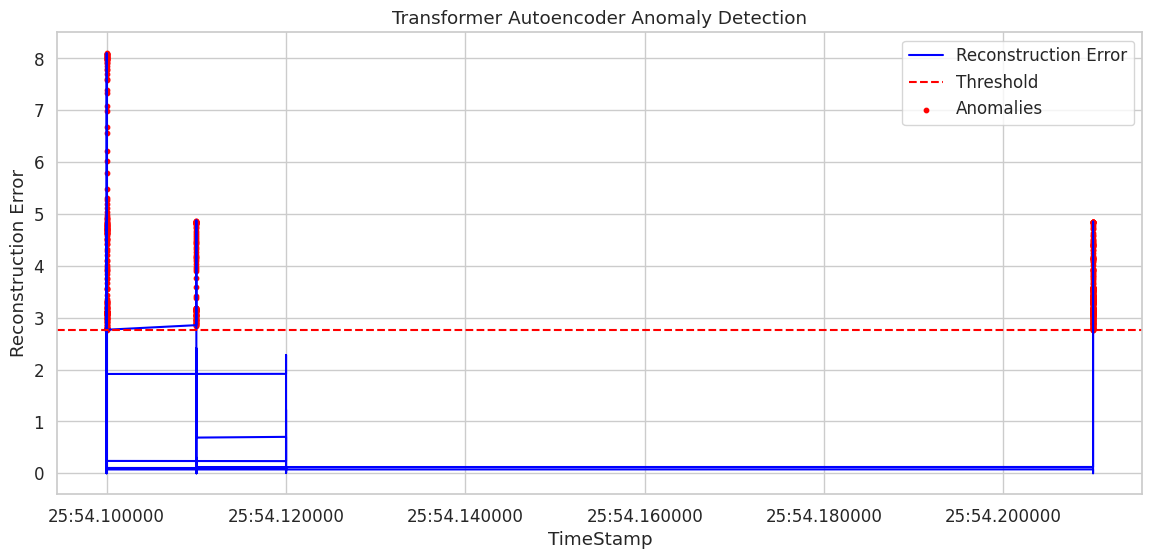

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

core_features = ['Gx','Gy','Gz','Ax','Ay','Az','Mx','My','Mz']
df_data = df[['TimeStamp']+core_features].copy()
df_data['A_mag']=np.sqrt(df_data['Ax']**2+df_data['Ay']**2+df_data['Az']**2)
df_data['G_mag']=np.sqrt(df_data['Gx']**2+df_data['Gy']**2+df_data['Gz']**2)
df_data['M_mag']=np.sqrt(df_data['Mx']**2+df_data['My']**2+df_data['Mz']**2)

scaler_z=StandardScaler()
Z_scores=scaler_z.fit_transform(df_data[core_features])
max_abs_Z=np.max(np.abs(Z_scores),axis=1)
df_data['Z_Anomaly_Label']=(max_abs_Z>3).astype(int)

features=core_features+['A_mag','G_mag','M_mag']
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_data[features])

window_size=50
X_seq=[]
for i in range(len(X_scaled)-window_size):
    X_seq.append(X_scaled[i:i+window_size])
X_seq=np.array(X_seq)
normal_seq=X_seq[df_data['Z_Anomaly_Label'][:-window_size]==0]
input_shape=(window_size,X_seq.shape[2])

def transformer_encoder(inputs,head_size,num_heads,ff_dim,dropout=0):
    x=layers.MultiHeadAttention(key_dim=head_size,num_heads=num_heads,dropout=dropout)(inputs,inputs)
    x=layers.Add()([x,inputs])
    x=layers.LayerNormalization(epsilon=1e-6)(x)
    x_ff=layers.Dense(ff_dim,activation="relu")(x)
    x_ff=layers.Dense(inputs.shape[-1])(x_ff)
    x=layers.Add()([x,x_ff])
    x=layers.LayerNormalization(epsilon=1e-6)(x)
    return x

inputs=layers.Input(shape=input_shape)
x=transformer_encoder(inputs,64,4,128,0.1)
x=transformer_encoder(x,64,4,128,0.1)
encoded=layers.GlobalAveragePooling1D()(x)
encoded=layers.Dense(32,activation="relu")(encoded)

x=layers.RepeatVector(window_size)(encoded)
x=transformer_encoder(x,64,4,128,0.1)
x=transformer_encoder(x,64,4,128,0.1)
outputs=layers.TimeDistributed(layers.Dense(X_seq.shape[2]))(x)

model=models.Model(inputs,outputs)
model.compile(optimizer='adam',loss='mse')
model.fit(normal_seq,normal_seq,epochs=10,batch_size=128,verbose=1)

reconstructed=model.predict(X_seq)
mse=np.mean(np.square(X_seq-reconstructed),axis=(1,2))
threshold=np.percentile(mse,99)
df_data=df_data.iloc[window_size:].copy()
df_data['Transformer_Prediction']=(mse>threshold).astype(int)

Y_true=df_data['Z_Anomaly_Label']
Y_pred=df_data['Transformer_Prediction']

print("\nConfusion Matrix:")
print(confusion_matrix(Y_true,Y_pred))
print("\nClassification Report:")
print(classification_report(Y_true,Y_pred,target_names=['Normal (0)','Anomaly (1)']))

plt.figure(figsize=(14,6))
plt.plot(df_data['TimeStamp'],mse,color='blue',label='Reconstruction Error')
plt.axhline(threshold,color='red',linestyle='--',label='Threshold')
plt.scatter(df_data['TimeStamp'][df_data['Transformer_Prediction']==1],
            mse[df_data['Transformer_Prediction']==1],
            color='red',s=10,label='Anomalies')
plt.xlabel("TimeStamp")
plt.ylabel("Reconstruction Error")
plt.title("Transformer Autoencoder Anomaly Detection")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

core_features=['Gx','Gy','Gz','Ax','Ay','Az','Mx','My','Mz']
df_data=df[core_features].copy()
df_data['A_mag']=np.sqrt(df_data['Ax']**2+df_data['Ay']**2+df_data['Az']**2)
df_data['G_mag']=np.sqrt(df_data['Gx']**2+df_data['Gy']**2+df_data['Gz']**2)
df_data['M_mag']=np.sqrt(df_data['Mx']**2+df_data['My']**2+df_data['Mz']**2)
scaler_z=StandardScaler()
Z_scores=scaler_z.fit_transform(df_data[core_features])
max_abs_Z=np.max(np.abs(Z_scores),axis=1)
df_data['Z_Anomaly_Label']=(max_abs_Z>3).astype(int)
features=core_features+['A_mag','G_mag','M_mag']
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_data[features])
num_nodes=X_scaled.shape[0]
adj=np.eye(num_nodes)
for i in range(num_nodes-1):
    adj[i,i+1]=adj[i+1,i]=1
adj=tf.constant(adj,dtype=tf.float32)
X=tf.constant(X_scaled,dtype=tf.float32)

class GraphConvolution(layers.Layer):
    def __init__(self,output_dim):
        super().__init__()
        self.output_dim=output_dim
    def build(self,input_shape):
        self.W=self.add_weight(shape=(input_shape[-1],self.output_dim),
                               initializer="glorot_uniform",trainable=True)
    def call(self,inputs,adj):
        h=tf.matmul(adj,inputs)
        h=tf.matmul(h,self.W)
        return tf.nn.relu(h)

class GCNEncoder(Model):
    def __init__(self,hidden_dim,latent_dim):
        super().__init__()
        self.gc1=GraphConvolution(hidden_dim)
        self.gc2=GraphConvolution(latent_dim)
    def call(self,X,adj):
        h=self.gc1(X,adj)
        z=self.gc2(h,adj)
        return z

class GCNDecoder(Model):
    def call(self,Z):
        return tf.matmul(Z,Z,transpose_b=True)

encoder=GCNEncoder(32,16)
decoder=GCNDecoder()
optimizer=tf.keras.optimizers.Adam(learning_rate=0.001)

for epoch in range(5):
    with tf.GradientTape() as tape:
        Z=encoder(X,adj)
        X_recon=decoder(Z)
        loss=tf.reduce_mean(tf.square(X_recon-tf.matmul(X,X,transpose_b=True)))
    grads=tape.gradient(loss,encoder.trainable_weights)
    optimizer.apply_gradients(zip(grads,encoder.trainable_weights))

Z_final=encoder(X,adj)
X_recon=tf.matmul(Z_final,Z_final,transpose_b=True)
recon_error=tf.reduce_mean(tf.square(X_recon-tf.matmul(X,X,transpose_b=True)),axis=1)
threshold=np.percentile(recon_error,99)
df_data['GNN_Prediction']=(recon_error.numpy()>threshold).astype(int)
Y_true=df_data['Z_Anomaly_Label']
Y_pred=df_data['GNN_Prediction']
print(confusion_matrix(Y_true,Y_pred))
print(classification_report(Y_true,Y_pred,target_names=['Normal (0)','Anomaly (1)']))
plt.figure(figsize=(12,6))
plt.plot(recon_error.numpy(),label='Reconstruction Error')
plt.axhline(threshold,color='red',linestyle='--',label='Threshold')
plt.scatter(np.where(df_data['GNN_Prediction']==1),
            recon_error.numpy()[df_data['GNN_Prediction']==1],
            color='red',s=10,label='Anomalies')
plt.legend()
plt.title("Graph Neural Network Autoencoder Anomaly Detection")
plt.show()


NameError: name 'df' is not defined